In [46]:
# Install libraries
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import pandas as pd
import numpy as np
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

In [47]:
CREDENTIAL_PATH = Path("colab-service-account.json")

scope = [
    "https://spreadsheets.google.com/feeds",
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
]

creds = ServiceAccountCredentials.from_json_keyfile_name(
    str(CREDENTIAL_PATH),
    scope
)

client = gspread.authorize(creds)


In [48]:
def read_sheet(spreadsheet_id, gid=None, sheet_name=None):
    """
    Baca Google Sheet menjadi DataFrame
    """
    sh = client.open_by_key(spreadsheet_id)

    if sheet_name:
        ws = sh.worksheet(sheet_name)
    elif gid:
        ws = sh.get_worksheet_by_id(int(gid))
    else:
        ws = sh.sheet1

    data = ws.get_all_records()
    return pd.DataFrame(data)

In [49]:
sheet2_id = "18fJ2U96koMRctfbhybT1HsT2D95wgafLQMzlb-AwTvE"
df_sheet2 = read_sheet(sheet2_id)
print("Sheet 2:")
df_sheet2.head()

Sheet 2:


,Sumber Sheet,Tanggal Gabungan,Month,Product,Kategori,Hari,Bulan,Tahun,Batch,Umur,...,Channel,Mengapa memilih Dibimbing,Pernah/Tidak memiliki pengalaman di bidang yang diambil,Apakah memiliki skill bahasa inggris,Penyaluran Kerja,Blog dibimbing,Community,Pernah ikut acara dibimbing/tidak,Catatan,Pengembalian Kontrak
0,DS,2/Jan/2024,Jan 2024,Data Science,JCJC+,2,Jan,2024,26,33,...,Instagram,"Job Connector dan kualitas dari Dibimbing, ser...","Job Connector dan kualitas dari Dibimbing, ser...",,Tertarik,,-,Tidak,,-
1,DE,2/Jan/2024,Jan 2024,Data Engineering,CAJC,2,Jan,2024,4,24,...,Instagram,"Karena harga affordable, waktunya tidak mengga...","Karena harga affordable, waktunya tidak mengga...",,,Tidak,,Tidak,Pernah mengikuti Bootcamp di Altera Academy un...,
2,PMPM,2/Jan/2024,Jan 2024,Product Management,JCJC+,2,Jan,2024,9,27,...,Google Ads,Kurikulum di Dibimbing paling sesuai dan harga...,Kurikulum di Dibimbing paling sesuai dan harga...,,tertarik,Tidak,Tidak,Tidak,,
3,DM,2/Jan/2024,Jan 2024,Digital Marketing,JCJC+,2,Jan,2024,23,29,...,Instagram,"Dari sisi silabus materinya lengkap, harganya ...","Dari sisi silabus materinya lengkap, harganya ...",,Tertarik,Tidak,Tidak,Pernah (mentortalks tahun 2023),-,-
4,UIUX,3/Jan/2024,Jan 2024,UI/UX,JCJC+,3,Jan,2024,24,24,...,Refferal,di Linkedin dan di CV diperbarui sehingga dapa...,di Linkedin dan di CV diperbarui sehingga dapa...,,Tertarik,,Tidak,Tidak,Pernah mengikuti Intern di rakaming dan bekerj...,


# Data Inspections

In [50]:
df_sheet2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 40 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Sumber Sheet                                             3071 non-null   str   
 1   Tanggal Gabungan                                         3071 non-null   str   
 2   Month                                                    3071 non-null   str   
 3   Product                                                  3071 non-null   str   
 4   Kategori                                                 3071 non-null   str   
 5   Hari                                                     3071 non-null   int64 
 6   Bulan                                                    3071 non-null   str   
 7   Tahun                                                    3071 non-null   int64 
 8   Batch                                            

In [51]:
df_sheet2.columns

Index(['Sumber Sheet', 'Tanggal Gabungan', 'Month', 'Product', 'Kategori',
       'Hari', 'Bulan', 'Tahun', 'Batch', 'Umur', 'Domisili', 'Kota',
       'Kota(Jabodetabek)', 'Provinsi', 'Negara', 'Background pendidikan',
       'Asal Sekolah', 'Level pendidikan', 'Jurusan pendidikan', 'Jurusan',
       'Jurusan S2 (jika ada)', 'Kesibukan sekarang apa', 'Kategori Kesibukan',
       'Level Pekerjaan', 'Kategori Pekerjaan',
       'Waktu terakhir bekerja (kalau lagi nggak kerja/intern)',
       'Kegiatan yang dilakukan waktu luang/Hobi',
       'Alasan mengambil kategori Bootcamp', 'Motivasi mengikuti bootcamp',
       'Dengar Dibimbing darimana', 'Channel', 'Mengapa memilih Dibimbing',
       'Pernah/Tidak memiliki pengalaman di bidang yang diambil',
       'Apakah memiliki skill bahasa inggris', 'Penyaluran Kerja',
       'Blog dibimbing', 'Community', 'Pernah ikut acara dibimbing/tidak',
       'Catatan', 'Pengembalian Kontrak'],
      dtype='str')

In [52]:
df_sheet2.describe()

,Hari,Tahun
count,3071.000000,3071.000000
mean,15.834582,2024.562683
std,8.736981,0.496136
min,1.000000,2024.000000
25%,8.000000,2024.000000
50%,16.000000,2025.000000
75%,23.000000,2025.000000
max,31.000000,2025.000000


In [53]:
for col in df_sheet2.columns:
    print(f"======= {col} =======")
    display(df_sheet2[col].nunique())
    print()

======= Sumber Sheet =======


27


======= Tanggal Gabungan =======


570


======= Month =======


...

87


======= Catatan =======


2267


======= Pengembalian Kontrak =======


2

In [54]:
for col in df_sheet2.columns:
    print(f"======= {col} =======")
    display(df_sheet2[col].value_counts())
    print()

======= Sumber Sheet =======


Sumber Sheet
DS            656
HR            351
DM            312
BI            252
UIUX          208
PMPM          191
ML            172
FE            162
DE            146
CS            123
BE             76
BD             68
FA             56
SCM            42
ESG_SM         40
QA             36
DABI           35
DSML           31
FWD            23
DS_Offline     20
MA             18
PR             16
IB             15
EP             13
DM_Offline      6
AU              2
HSE             1
Name: count, dtype: int64


======= Tanggal Gabungan =======


Tanggal Gabungan
26/Jun/2025    16
29/Jun/2025    16
30/Jul/2024    12
6/Agu/2024     12
2/Jul/2024     10
               ..
15/Des/2024     1
18/Feb/2025     1
31/Mar/2025     1
12/Apr/2025     1
13/Apr/2025     1
Name: count, Length: 570, dtype: int64


======= Month =======


...

Pernah ikut acara dibimbing/tidak
Tidak                                                                            2786
Ya                                                                                189
Tidak                                                                               7
Iya                                                                                 4
                                                                                    3
                                                                                 ... 
Ya (pernah ikut bootcamp BI Batch 3 dan saat ini menjadi alumni)                    1
Ya (Pernah mengikuti DSF UI/UX  selama 2 hari dengan mentor Kak Fadel)              1
\nTidak                                                                             1
Ya (pernah mengikuti DSF untuk topik Project Management pada tahun ini)             1
Ya (pernah mengikuti DSF dengan topik Human Resource kurang lebih tahun lalu)       1
Name: count, Length:


======= Catatan =======


Catatan
-                                                                                                                                                                                                                                                                                 384
                                                                                                                                                                                                                                                                                   70
Instagram Ads (tahu Dibimbing dari ads instagram lalu dilihat-lihat tertarik dan register)                                                                                                                                                                                         32
Instagram Ads (tahu Dibimbing dari ads instagram tiba-tiba muncul lalu dilihat-lihat tertarik dan register)                                                   


======= Pengembalian Kontrak =======


Pengembalian Kontrak
-    2351
      720
Name: count, dtype: int64

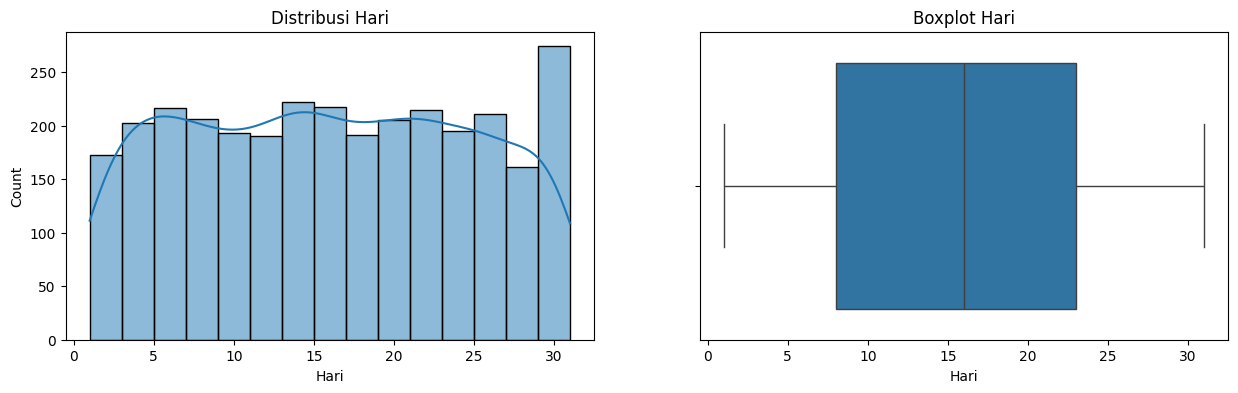

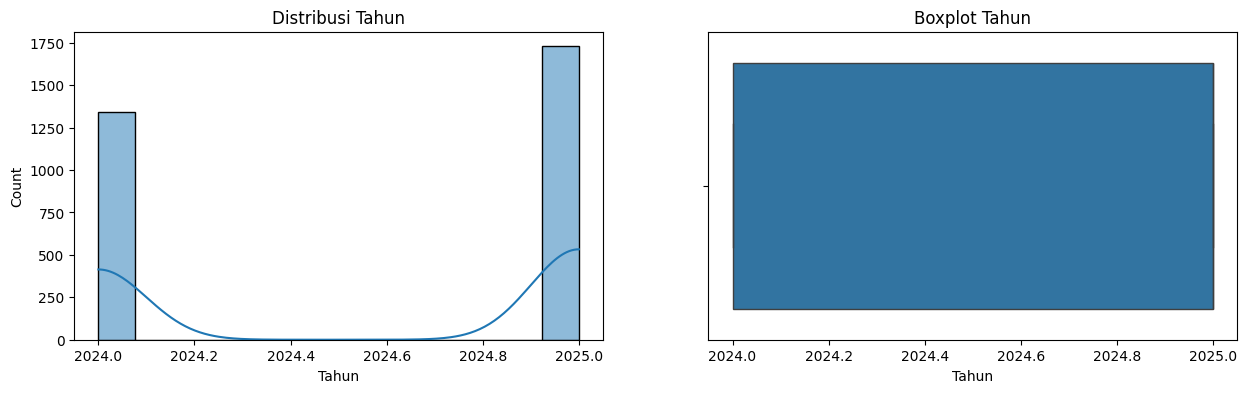

In [55]:
num = df_sheet2.select_dtypes(include=[np.number]).columns

for col in num:
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    sns.histplot(df_sheet2[col], kde=True)
    plt.title(f"Distribusi {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df_sheet2[col])
    plt.title(f"Boxplot {col}")

    plt.show()

## Data Understanding

The dataset consists of 3,071 rows and 40 columns, representing participant and sales-related information from multiple sources. The dataset spans January 2024 to October 2025 and covers both online and offline programs. Each row corresponds to a single participant or transaction record, includes:
1.	Source & Program Information
    - Sumber Sheet: Origin of the data source, representing different bootcamp programs (e.g., Data Science, Digital Marketing, HR, UI/UX).
    - Product: Bootcamp product name (e.g., Data Science, Product Management, Cyber Security).
    - Kategori: Program type classification (e.g., JCJC+, CAJC).
2. Temporal Information
    - Tanggal Gabungan: Enrollment or registration date (string format).
    - Month, Bulan, Hari, Tahun: Derived date components.

    -> The presence of multiple time-related columns introduces redundancy and inconsistency risk, as the same date information is represented in different formats and languages.
3. Demographic & Geographic Attributes
    - Umur: Participant age (numeric and text-mixed).
    - Domisili, Kota, Provinsi, Negara
    - Kota (Jabodetabek): Geographic grouping indicator.
4. Education Background
    - Background pendidikan
    - Asal Sekolah
    - Level pendidikan
    - Jurusan pendidikan
    - Jurusan
    - Jurusan S2 (jika ada)
5. Employment & Career Status
    - Kesibukan sekarang apa
    - Kategori Kesibukan
    - Level Pekerjaan
    - Kategori Pekerjaan
    - Waktu terakhir bekerja
6. Marketing & Behavioral Information
    - Dengar Dibimbing darimana
    - Channel
    - Mengapa memilih Dibimbing
    - Alasan mengambil kategori Bootcamp
    - Motivasi mengikuti bootcamp
7. Outcome & Engagement Indicators
    - Pernah/Tidak memiliki pengalaman di bidang yang diambil
    - Apakah memiliki skill bahasa inggris
    - Penyaluran Kerja
    - Blog dibimbing
    - Community
    - Pernah ikut acara dibimbing/tidak
    - Pengembalian Kontrak
- Several columns are stored as object data types despite representing structured or ordinal information, such as:
    - Tanggal Gabungan (date)
    - Umur (age group)
    - Time-related fields (Month, Bulan)
    
    However, the time data overlaps with the date column, so it's reasonable to drop it.
- The dataset is indicated to have no missing values, as all columns contain 3,071 non-null entries. Howevery, after checking the data through google sheets, there are data that contains empty strings, hyphens (-), or whitespace. The columns are Kategori, Blog dibimbing, Community, Jurusan S2, 
- There are also several columns contains inconsistent value that need to be normalized and cleaning. The columns are Dengar Dibimbing darimana, Channel, Penyaluran Kerja, Blog dibimbing, Community, Pernah ikut acara dibimbing/tidak, Kategori Kesibukan, Level Pekerjaan, Level pendidikan.
- There is columns that contain mixed data types (numeric and non-numeric value), such as umur. 
- There are several columns with hundreds to thousands of unique values, in other words is "high cardinality free text", 

# Data Preparation

In [56]:
df_sheet2.columns

Index(['Sumber Sheet', 'Tanggal Gabungan', 'Month', 'Product', 'Kategori',
       'Hari', 'Bulan', 'Tahun', 'Batch', 'Umur', 'Domisili', 'Kota',
       'Kota(Jabodetabek)', 'Provinsi', 'Negara', 'Background pendidikan',
       'Asal Sekolah', 'Level pendidikan', 'Jurusan pendidikan', 'Jurusan',
       'Jurusan S2 (jika ada)', 'Kesibukan sekarang apa', 'Kategori Kesibukan',
       'Level Pekerjaan', 'Kategori Pekerjaan',
       'Waktu terakhir bekerja (kalau lagi nggak kerja/intern)',
       'Kegiatan yang dilakukan waktu luang/Hobi',
       'Alasan mengambil kategori Bootcamp', 'Motivasi mengikuti bootcamp',
       'Dengar Dibimbing darimana', 'Channel', 'Mengapa memilih Dibimbing',
       'Pernah/Tidak memiliki pengalaman di bidang yang diambil',
       'Apakah memiliki skill bahasa inggris', 'Penyaluran Kerja',
       'Blog dibimbing', 'Community', 'Pernah ikut acara dibimbing/tidak',
       'Catatan', 'Pengembalian Kontrak'],
      dtype='str')

In [57]:
df_sheet2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 40 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Sumber Sheet                                             3071 non-null   str   
 1   Tanggal Gabungan                                         3071 non-null   str   
 2   Month                                                    3071 non-null   str   
 3   Product                                                  3071 non-null   str   
 4   Kategori                                                 3071 non-null   str   
 5   Hari                                                     3071 non-null   int64 
 6   Bulan                                                    3071 non-null   str   
 7   Tahun                                                    3071 non-null   int64 
 8   Batch                                            

In [58]:
# Standaridze Column Names
df_sheet2.columns = (
    df_sheet2.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[()/]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

# Drop Columns
df_sheet2 = df_sheet2.drop(columns=["hari", "bulan", "month", "tahun"], errors="ignore")

df_sheet2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 36 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   sumber_sheet                                            3071 non-null   str   
 1   tanggal_gabungan                                        3071 non-null   str   
 2   product                                                 3071 non-null   str   
 3   kategori                                                3071 non-null   str   
 4   batch                                                   3071 non-null   object
 5   umur                                                    3071 non-null   object
 6   domisili                                                3071 non-null   str   
 7   kota                                                    3071 non-null   str   
 8   kotajabodetabek                                         307

In [59]:
col = ["batch", "umur"]

for c in col:
    print(f"======= {c} =======")
    display(df_sheet2[c].value_counts())
    print()

======= batch =======


batch
1      290
2      161
3      123
7      115
4       97
      ... 
27B      1
         1
42+      1
6+       1
42       1
Name: count, Length: 92, dtype: int64


======= umur =======


umur
24                  403
23                  387
25                  344
22                  342
26                  257
27                  222
21                  166
28                  151
29                  133
30                  120
20                   85
32                   70
31                   68
33                   50
19                   42
34                   38
18                   33
36                   20
35                   17
38                   11
37                   11
44                    8
17                    8
40                    7
39                    7
16                    7
42                    6
50                    5
45                    5
48                    5
43                    4
41                    4
47                    3
15                    3
46                    2
                      2
49                    2
24 Tahun              2
29 tahun              2
25 tahun              2
55                    2
51         

In [60]:
# Standarize Format Columns
df_sheet2["batch"] = (
    df_sheet2["batch"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
)

df_sheet2["umur"] = (
    df_sheet2["umur"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

for c in col:
    print(f"======= {c} =======")
    display(df_sheet2[c].value_counts())
    print()
    print(df_sheet2[c].dtype)

======= batch =======


batch
1.0     297
2.0     174
3.0     134
27.0    132
32.0    116
7.0     115
28.0    107
33.0    103
29.0    101
4.0      99
26.0     97
5.0      95
6.0      95
8.0      92
30.0     91
12.0     83
10.0     81
31.0     76
11.0     75
25.0     68
13.0     63
19.0     58
14.0     57
9.0      54
24.0     53
15.0     50
17.0     48
37.0     46
36.0     45
18.0     44
34.0     40
16.0     39
39.0     37
23.0     36
35.0     34
38.0     33
20.0     29
40.0     29
22.0     23
21.0     17
42.0      2
41.0      2
Name: count, dtype: int64


float64
======= umur =======


umur
24.0    406
23.0    388
25.0    346
22.0    344
26.0    259
27.0    222
21.0    167
28.0    153
29.0    135
30.0    120
20.0     85
32.0     70
31.0     68
33.0     50
19.0     42
34.0     38
18.0     33
36.0     20
35.0     17
38.0     11
37.0     11
39.0      8
44.0      8
17.0      8
40.0      7
16.0      7
42.0      6
50.0      5
45.0      5
48.0      5
43.0      4
41.0      4
47.0      3
15.0      3
46.0      2
49.0      2
55.0      2
51.0      1
53.0      1
54.0      1
52.0      1
Name: count, dtype: int64


float64


In [61]:
cat_cols = df_sheet2.select_dtypes(include=["object"]).columns

for col in cat_cols:
    count = (
        df_sheet2[col]
        .astype(str)
        .str.strip()
        .isin(["", "-"])
        .sum()
    )
    print(f"{col}: {count}")


sumber_sheet: 0
tanggal_gabungan: 0
product: 1
kategori: 1
domisili: 2
kota: 77
kotajabodetabek: 77
provinsi: 6
negara: 6
background_pendidikan: 2
asal_sekolah: 35
level_pendidikan: 9
jurusan_pendidikan: 557
jurusan: 575
jurusan_s2_jika_ada: 2823
kesibukan_sekarang_apa: 3
kategori_kesibukan: 3
level_pekerjaan: 10
kategori_pekerjaan: 10
waktu_terakhir_bekerja_kalau_lagi_nggak_kerjaintern: 2220
kegiatan_yang_dilakukan_waktu_luanghobi: 1558
alasan_mengambil_kategori_bootcamp: 545
motivasi_mengikuti_bootcamp: 212
dengar_dibimbing_darimana: 18
channel: 18
mengapa_memilih_dibimbing: 24
pernahtidak_memiliki_pengalaman_di_bidang_yang_diambil: 13
apakah_memiliki_skill_bahasa_inggris: 724
penyaluran_kerja: 169
blog_dibimbing: 1410
community: 573
pernah_ikut_acara_dibimbingtidak: 4
catatan: 454
pengembalian_kontrak: 3071


C:\Users\user\AppData\Local\Temp\ipykernel_1212\864240788.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_sheet2.select_dtypes(include=["object"]).columns


In [62]:
# Standarize White Spaces and Hypens to NaN
df_sheet2[cat_cols] = (df_sheet2[cat_cols].astype(str).apply(lambda s: s.str.strip()).replace(["", "-"], np.nan))
df_sheet2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 36 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   sumber_sheet                                            3071 non-null   str    
 1   tanggal_gabungan                                        3071 non-null   str    
 2   product                                                 3070 non-null   str    
 3   kategori                                                3070 non-null   str    
 4   batch                                                   3070 non-null   float64
 5   umur                                                    3068 non-null   float64
 6   domisili                                                3069 non-null   str    
 7   kota                                                    2994 non-null   str    
 8   kotajabodetabek                                  

In [63]:
print(df_sheet2.isna().sum())

# Presentase Missing Values
missing_percentage = ((df_sheet2.isna().sum() / len(df_sheet2)) * 100).round(2)
missing_percentage = missing_percentage[missing_percentage > 0]
missing_percentage

sumber_sheet                                                 0
tanggal_gabungan                                             0
product                                                      1
kategori                                                     1
batch                                                        1
umur                                                         3
domisili                                                     2
kota                                                        77
kotajabodetabek                                             77
provinsi                                                     6
negara                                                       6
background_pendidikan                                        2
asal_sekolah                                                35
level_pendidikan                                             9
jurusan_pendidikan                                         557
jurusan                                                

product                                                     0.03
kategori                                                    0.03
batch                                                       0.03
umur                                                        0.10
domisili                                                    0.07
kota                                                        2.51
kotajabodetabek                                             2.51
provinsi                                                    0.20
negara                                                      0.20
background_pendidikan                                       0.07
asal_sekolah                                                1.14
level_pendidikan                                            0.29
jurusan_pendidikan                                         18.14
jurusan                                                    18.72
jurusan_s2_jika_ada                                        91.92
kesibukan_sekarang_apa   

In [64]:
df_sheet2.head()

,sumber_sheet,tanggal_gabungan,product,kategori,batch,umur,domisili,kota,kotajabodetabek,provinsi,...,channel,mengapa_memilih_dibimbing,pernahtidak_memiliki_pengalaman_di_bidang_yang_diambil,apakah_memiliki_skill_bahasa_inggris,penyaluran_kerja,blog_dibimbing,community,pernah_ikut_acara_dibimbingtidak,catatan,pengembalian_kontrak
0,DS,2/Jan/2024,Data Science,JCJC+,26.0,33.0,Yogyakarta,Yogyakarta,Yogyakarta,Yogyakarta,...,Instagram,"Job Connector dan kualitas dari Dibimbing, ser...","Job Connector dan kualitas dari Dibimbing, ser...",NaN,Tertarik,NaN,NaN,Tidak,NaN,NaN
1,DE,2/Jan/2024,Data Engineering,CAJC,4.0,24.0,Jakarta Barat,Jakarta,Jabodetabek,DKI Jakarta,...,Instagram,"Karena harga affordable, waktunya tidak mengga...","Karena harga affordable, waktunya tidak mengga...",NaN,NaN,Tidak,NaN,Tidak,Pernah mengikuti Bootcamp di Altera Academy un...,NaN
2,PMPM,2/Jan/2024,Product Management,JCJC+,9.0,27.0,Jakarta Selatan,Jakarta,Jabodetabek,DKI Jakarta,...,Google Ads,Kurikulum di Dibimbing paling sesuai dan harga...,Kurikulum di Dibimbing paling sesuai dan harga...,NaN,tertarik,Tidak,Tidak,Tidak,NaN,NaN
3,DM,2/Jan/2024,Digital Marketing,JCJC+,23.0,29.0,Balikpapan,Bali,Bali,Bali,...,Instagram,"Dari sisi silabus materinya lengkap, harganya ...","Dari sisi silabus materinya lengkap, harganya ...",NaN,Tertarik,Tidak,Tidak,Pernah (mentortalks tahun 2023),NaN,NaN
4,UIUX,3/Jan/2024,UI/UX,JCJC+,24.0,24.0,Boyolali,Boyolali,Boyolali,Jawa Tengah,...,Refferal,di Linkedin dan di CV diperbarui sehingga dapa...,di Linkedin dan di CV diperbarui sehingga dapa...,NaN,Tertarik,NaN,Tidak,Tidak,Pernah mengikuti Intern di rakaming dan bekerj...,NaN


In [65]:
# Standarize Format
df_sheet2["domisili_clean"] = (
    df_sheet2["domisili"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"-": np.nan, "": np.nan})
)

# Mapping Domisili
jabodetabek_keywords = [
    "jakarta", "bogor", "depok", "tangerang", "bekasi"
]
java_provinces = [
    "jawa barat", "jawa tengah", "jawa timur",
    "banten", "dki jakarta", "di yogyakarta", "yogyakarta"
]

# Function to map domisili
def map_region(text):
    if pd.isna(text):
        return "unknown"
    
    if text == "keberatan":
        return "unknown"
    
    # Jabodetabek
    if any(k in text for k in jabodetabek_keywords):
        return "jabodetabek"
    
    # Java (non Jabodetabek)
    if any(p in text for p in java_provinces):
        return "java_non_jabodetabek"
    
    return "outside_java"

# Apply mapping
df_sheet2["region"] = df_sheet2["domisili_clean"].apply(map_region)
df_sheet2["region"].value_counts()

region
jabodetabek             1505
outside_java            1050
java_non_jabodetabek     513
unknown                    3
Name: count, dtype: int64

In [66]:
df_sheet2.columns

Index(['sumber_sheet', 'tanggal_gabungan', 'product', 'kategori', 'batch',
       'umur', 'domisili', 'kota', 'kotajabodetabek', 'provinsi', 'negara',
       'background_pendidikan', 'asal_sekolah', 'level_pendidikan',
       'jurusan_pendidikan', 'jurusan', 'jurusan_s2_jika_ada',
       'kesibukan_sekarang_apa', 'kategori_kesibukan', 'level_pekerjaan',
       'kategori_pekerjaan',
       'waktu_terakhir_bekerja_kalau_lagi_nggak_kerjaintern',
       'kegiatan_yang_dilakukan_waktu_luanghobi',
       'alasan_mengambil_kategori_bootcamp', 'motivasi_mengikuti_bootcamp',
       'dengar_dibimbing_darimana', 'channel', 'mengapa_memilih_dibimbing',
       'pernahtidak_memiliki_pengalaman_di_bidang_yang_diambil',
       'apakah_memiliki_skill_bahasa_inggris', 'penyaluran_kerja',
       'blog_dibimbing', 'community', 'pernah_ikut_acara_dibimbingtidak',
       'catatan', 'pengembalian_kontrak', 'domisili_clean', 'region'],
      dtype='str')

In [67]:
eda_cols = ['tanggal_gabungan', 'product', 'kategori', 'batch', 'umur', 'region', 
            'kategori_kesibukan', 'kategori_pekerjaan', 'motivasi_mengikuti_bootcamp', 'channel', 'mengapa_memilih_dibimbing'
       ]

eda = df_sheet2[eda_cols]
eda

,tanggal_gabungan,product,kategori,batch,umur,region,kategori_kesibukan,kategori_pekerjaan,motivasi_mengikuti_bootcamp,channel,mengapa_memilih_dibimbing
0,2/Jan/2024,Data Science,JCJC+,26.0,33.0,java_non_jabodetabek,Job seeker,Job Seeker,memiliki presepsi jika data science itu membut...,Instagram,"Job Connector dan kualitas dari Dibimbing, ser..."
1,2/Jan/2024,Data Engineering,CAJC,4.0,24.0,jabodetabek,Pekerja,PNS,motivasi mengikuti bootcamp sata engineering k...,Instagram,"Karena harga affordable, waktunya tidak mengga..."
2,2/Jan/2024,Product Management,JCJC+,9.0,27.0,jabodetabek,Pekerja,Karyawan Swasta,NaN,Google Ads,Kurikulum di Dibimbing paling sesuai dan harga...
3,2/Jan/2024,Digital Marketing,JCJC+,23.0,29.0,outside_java,Pekerja,Karyawan (di anak perusahaan PLN yaitu PLN Nus...,pengen switch career di Digital Marketing kare...,Instagram,"Dari sisi silabus materinya lengkap, harganya ..."
4,3/Jan/2024,UI/UX,JCJC+,24.0,24.0,outside_java,Pekerja,Freelance (Karadividia Yoyakarta sebagai Noteker),karena sebelumnya sudah pegang UX Designer seh...,Refferal,di Linkedin dan di CV diperbarui sehingga dapa...
...,...,...,...,...,...,...,...,...,...,...,...
3066,1/Nov/2025,ESG & Sustainability,CAJC,2.0,24.0,jabodetabek,Job seeker,Job Seeker,Tertarik mengikuti bootcamp karena berdasar pa...,Instagram,Ketersediaan program ESG-SM dan sistem bootcamp
3067,2/Nov/2025,ESG & Sustainability,CAJC,1.0,23.0,jabodetabek,Pekerja,Karyawan Swasta,Motivasi mengikuti bootcamp karena ingin switc...,Instagram,Latar belakang ketersediaan ESG karena ada dem...
3068,2/Nov/2025,Data Science & Machine Learning,CAJC,41.0,26.0,jabodetabek,Pekerja,Karyawan Swasta,tertarik mengikuti bootcamp karena ingin mempe...,Organic,"Silabus, harga affordable dan metode pembayara..."
3069,2/Nov/2025,Data Analyst & Business Intelligence,JCJC+,20.0,22.0,jabodetabek,Job seeker,Job Seeker,Ketika kuliah belajar bahasa pemrogramannya se...,TikTok Ads,Review di Tiktok (dia belum pernah compare den...


In [68]:
for c in eda_cols:
    print(f"======= {c} =======")
    display(eda[c].value_counts())
    print()

======= tanggal_gabungan =======


tanggal_gabungan
26/Jun/2025    16
29/Jun/2025    16
30/Jul/2024    12
6/Agu/2024     12
2/Jul/2024     10
               ..
15/Des/2024     1
18/Feb/2025     1
31/Mar/2025     1
12/Apr/2025     1
13/Apr/2025     1
Name: count, Length: 570, dtype: int64


======= product =======


product
Data Science                            656
Human Resource                          351
Digital Marketing                       312
Business Intelligence                   252
UI/UX                                   208
Product Management                      191
AI Machine Learning                     172
Web Development (FE)                    162
Data Engineering                        146
Cyber Security                          123
Back End Golang                          76
Business Development                     68
Finance & Accounting                     56
Supply Chain Management                  42
ESG & Sustainability                     40
Quality Assurance                        36
Data Analyst & Business Intelligence     35
Data Science & Machine Learning          31
Fullstack Web-Dev                        23
Data Science (Offline)                   20
Mobile App                               18
Public Relation                          16
Investment Banking      


======= kategori =======


...

motivasi_mengikuti_bootcamp
Untuk front end setelah mengenal programming tertarik karena dia suka tantangan dan belajar hal baru dan dari sisi lapangan pekerjaan kedepan di bidang ini banyak yang dicari dan jika dia sudah menguasai front end web development ingin membuka freelance, sehingga untuk tujuan utamanya selain untuk mengembangkan skill sebelumnya untuk menunjang career dan untuk pekerjaan sampingan                                                                                                                                                                                                                                                                                                                                                                                                                                  2
karena ingin berpindah kair dan dilihat di jaman sekarang bidang data ini sengat banyak peluang dan ingin memperdalam ini agar lebih bisa bekerja dimana saja             


======= channel =======


channel
Meta Ads      784
Refferal      754
Instagram     534
Organic       482
Google Ads    188
TikTok Ads     86
KOL            74
Linkedin       52
TikTok         45
Youtube        31
Twitter        17
Facebook        5
YouTube         1
Name: count, dtype: int64


======= mengapa_memilih_dibimbing =======


mengapa_memilih_dibimbing
Testimoni                                                                                                                                                                                                                                                                                                                                                                                                          16
Job connector                                                                                                                                                                                                                                                                                                                                                                                                      11
Waktu (di weekend)                                                                                                                                                

In [69]:
print(eda.info())
print(eda.isna().sum())

# Presentase Missing Values
missing_percentage = ((eda.isna().sum() / len(eda)) * 100).round(2)
missing_percentage = missing_percentage[missing_percentage > 0]
missing_percentage

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tanggal_gabungan             3071 non-null   str    
 1   product                      3070 non-null   str    
 2   kategori                     3070 non-null   str    
 3   batch                        3070 non-null   float64
 4   umur                         3068 non-null   float64
 5   region                       3071 non-null   str    
 6   kategori_kesibukan           3068 non-null   str    
 7   kategori_pekerjaan           3061 non-null   str    
 8   motivasi_mengikuti_bootcamp  2859 non-null   str    
 9   channel                      3053 non-null   str    
 10  mengapa_memilih_dibimbing    3047 non-null   str    
dtypes: float64(2), str(9)
memory usage: 264.0 KB
None
tanggal_gabungan                 0
product                          1
kategori                 

product                        0.03
kategori                       0.03
batch                          0.03
umur                           0.10
kategori_kesibukan             0.10
kategori_pekerjaan             0.33
motivasi_mengikuti_bootcamp    6.90
channel                        0.59
mengapa_memilih_dibimbing      0.78
dtype: float64

In [70]:
# normalized date
bulan_map = {
    "jan": "jan",
    "feb": "feb",
    "mar": "mar",
    "apr": "apr",
    "mei": "may",
    "jun": "jun",
    "jul": "jul",
    "agu": "aug",
    "sep": "sep",
    "okt": "oct",
    "nov": "nov",
    "des": "dec"
}
eda["tanggal_gabungan"] = (
    eda["tanggal_gabungan"]
    .str.lower()
    .replace(bulan_map, regex=True)
)
eda["tanggal_gabungan"] = pd.to_datetime(
    eda["tanggal_gabungan"],
    format="%d/%b/%Y",
    errors="coerce"
)

eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   tanggal_gabungan             3071 non-null   datetime64[us]
 1   product                      3070 non-null   str           
 2   kategori                     3070 non-null   str           
 3   batch                        3070 non-null   float64       
 4   umur                         3068 non-null   float64       
 5   region                       3071 non-null   str           
 6   kategori_kesibukan           3068 non-null   str           
 7   kategori_pekerjaan           3061 non-null   str           
 8   motivasi_mengikuti_bootcamp  2859 non-null   str           
 9   channel                      3053 non-null   str           
 10  mengapa_memilih_dibimbing    3047 non-null   str           
dtypes: datetime64[us](1), float64(2), str(8)
memory usage:

In [71]:
# Cleaned kategori_pekerjaan
eda["kategori_pekerjaan"] = (
    eda["kategori_pekerjaan"]
    .astype(str)               # string
    .str.strip()               # remove space
    .str.lower()               # lowercase
    .str.replace(r"\s+", " ", regex=True)  # remove double space
    .str.replace(r"[^a-zA-Z\s]", "", regex=True)  # remove unuiqe character
)
def classify_job(x):

    if pd.isna(x):
        return "Unknown"

    # STUDENT
    if any(word in x for word in ["mahasiswa", "pelajar", "siswa"]):
        return "Student"

    # JOB SEEKER
    if any(word in x for word in ["job seeker", "jobseeker", "menganggur", "tidak bekerja", "fresh graduate"]):
        return "Job Seeker / Unemployed"

    # GOVERNMENT
    if any(word in x for word in ["pns", "asn", "pegawai negeri", "pemerintah", "bumn"]):
        return "Government Employee"

    # HEALTHCARE
    if any(word in x for word in ["dokter", "perawat", "nakes", "kesehatan"]):
        return "Healthcare Professional"

    # ACADEMIC
    if any(word in x for word in ["dosen", "pengajar", "peneliti", "tenaga pengajar"]):
        return "Academic / Education"

    # ENTREPRENEUR
    if any(word in x for word in ["wirausaha", "wiraswasta", "pengusaha", "business", "pedagang", "cofounder"]):
        return "Entrepreneur / Self-Employed"

    # FREELANCE
    if any(word in x for word in ["freelance", "freelancer", "part time", "parttime", "paruh waktu"]):
        return "Freelancer / Part-Time"

    # INTERNSHIP
    if any(word in x for word in ["magang", "intern"]):
        return "Internship"

    # PRIVATE EMPLOYEE
    if any(word in x for word in ["karyawan", "pegawai", "kontrak", "officer", "buruh", "full time", "contract"]):
        return "Private Employee"

    return "Other"
eda["kategori_pekerjaan"] = eda["kategori_pekerjaan"].apply(classify_job)

print(eda["kategori_pekerjaan"].value_counts())

kategori_pekerjaan
Private Employee                1160
Job Seeker / Unemployed          996
Student                          451
Freelancer / Part-Time           158
Entrepreneur / Self-Employed     103
Government Employee               73
Other                             56
Academic / Education              36
Healthcare Professional           18
Internship                        10
Unknown                           10
Name: count, dtype: int64


In [72]:
# Generate World Cloud
eda['combined'] = (
    eda['motivasi_mengikuti_bootcamp'].fillna('') + ' ' +
    eda['mengapa_memilih_dibimbing'].fillna('')
)

# Download stopwords if needed
nltk.download('stopwords')

# Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text)           # remove extra spaces
    
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

eda['motivation_cloud'] = eda['combined'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [73]:
eda["channel"] = (
    eda["channel"]
    .str.strip()
    .str.lower()
)
def classify_channel(x):
    if pd.isna(x):
        return "other"
    if "google" in x:
        return "google"
    if "tiktok" in x:
        return "tiktok"
    if "instagram" in x or "meta" in x:
        return "instagram"
    if "linkedin" in x:
        return "linkedin"
    if "youtube" in x:
        return "youtube"
    if "twitter" in x:
        return "twitter"
    if "facebook" in x:
        return "facebook"
    if "referral" in x or "refferal" in x:
        return "referral"
    if "kol" in x or "influencer" in x:
        return "influencer"
    return "other"
eda["channel_clean"] = eda["channel"].apply(classify_channel)

print(eda["channel_clean"].value_counts())

channel_clean
instagram     1318
referral       754
other          500
google         188
tiktok         131
influencer      74
linkedin        52
youtube         32
twitter         17
facebook         5
Name: count, dtype: int64


In [74]:
eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   tanggal_gabungan             3071 non-null   datetime64[us]
 1   product                      3070 non-null   str           
 2   kategori                     3070 non-null   str           
 3   batch                        3070 non-null   float64       
 4   umur                         3068 non-null   float64       
 5   region                       3071 non-null   str           
 6   kategori_kesibukan           3068 non-null   str           
 7   kategori_pekerjaan           3071 non-null   str           
 8   motivasi_mengikuti_bootcamp  2859 non-null   str           
 9   channel                      3053 non-null   str           
 10  mengapa_memilih_dibimbing    3047 non-null   str           
 11  combined                     3071 non-null   str      

In [75]:
drop_cols = ['motivasi_mengikuti_bootcamp', 'channel', 'mengapa_memilih_dibimbing']
eda = eda.drop(columns=drop_cols)

print(eda.info())
print(eda.isna().sum())

# Presentase Missing Values
missing_percentage = ((eda.isna().sum() / len(eda)) * 100).round(2)
missing_percentage = missing_percentage[missing_percentage > 0]
missing_percentage

<class 'pandas.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tanggal_gabungan    3071 non-null   datetime64[us]
 1   product             3070 non-null   str           
 2   kategori            3070 non-null   str           
 3   batch               3070 non-null   float64       
 4   umur                3068 non-null   float64       
 5   region              3071 non-null   str           
 6   kategori_kesibukan  3068 non-null   str           
 7   kategori_pekerjaan  3071 non-null   str           
 8   combined            3071 non-null   str           
 9   motivation_cloud    3071 non-null   str           
 10  channel_clean       3071 non-null   str           
dtypes: datetime64[us](1), float64(2), str(8)
memory usage: 264.0 KB
None
tanggal_gabungan      0
product               1
kategori              1
batch                 1
umur  

product               0.03
kategori              0.03
batch                 0.03
umur                  0.10
kategori_kesibukan    0.10
dtype: float64

In [76]:
# display isna row
eda[eda.isna().any(axis=1)]

,tanggal_gabungan,product,kategori,batch,umur,region,kategori_kesibukan,kategori_pekerjaan,combined,motivation_cloud,channel_clean
786,2024-09-02,Business Intelligence,CAJC,13.0,NaN,unknown,Pekerja,Private Employee,Untuk tujuan ingin mempelajari hal-hal baru un...,tuju ajar business intelligence ajar programmi...,google
1098,2024-11-12,Human Resource,CAJC,4.0,NaN,jabodetabek,Pekerja,Private Employee,karena sebelumnya sudah pernah backup kerjaan ...,backup kerja hr detail jurus kuliah ambil mana...,instagram
1804,2025-03-16,UI/UX,JCJC+,30.0,24.0,jabodetabek,NaN,Unknown,Karena dulu waktu kuliah aktif organisasi dan ...,kuliah aktif organisasi tanggung bidang desain...,google
2353,2025-07-04,Web Development (FE),JCJC+,NaN,NaN,unknown,NaN,Unknown,,,other
2902,2025-10-06,Data Science & Machine Learning,CAJC,40.0,37.0,jabodetabek,NaN,Unknown,,,other
3057,2025-10-29,NaN,NaN,1.0,22.0,java_non_jabodetabek,Job seeker,Job Seeker / Unemployed,Dia dari jurusan Geografi/Pembangunan Wilayah ...,jurus geografi bangun wilayah relate bidang hs...,instagram


In [77]:
# handling missing value eda
eda['product'] = eda['product'].fillna(eda['product'].mode()[0])
eda['kategori'] = eda['kategori'].fillna(eda['kategori'].mode()[0])
eda['batch'] = eda['batch'].fillna(25)
eda['umur'] = eda['umur'].fillna(eda['umur'].median())
eda['kategori_kesibukan'] = eda['kategori_kesibukan'].fillna('Unknown')

print(eda.isna().sum())

tanggal_gabungan      0
product               0
kategori              0
batch                 0
umur                  0
region                0
kategori_kesibukan    0
kategori_pekerjaan    0
combined              0
motivation_cloud      0
channel_clean         0
dtype: int64


# Problem Statement

In [78]:
# filter produk
DS = df_sheet2.copy()
DS = DS[DS['product'] == 'Data Science'].sort_values(by='batch', ascending=False)
DS['batch'].value_counts()

batch
32.0    74
33.0    71
27.0    68
37.0    46
36.0    45
30.0    41
28.0    41
39.0    37
26.0    37
34.0    36
29.0    35
35.0    34
38.0    33
31.0    30
25.0    25
40.0     2
42.0     1
Name: count, dtype: int64

In [79]:
# filter produk
DS = df_sheet2.copy()
DS = DS[DS['product'] == 'Data Science']

DS[['batch']].value_counts().sort_index()

batch
25.0     25
26.0     37
27.0     68
28.0     41
29.0     35
30.0     41
31.0     30
32.0     74
33.0     71
34.0     36
35.0     34
36.0     45
37.0     46
38.0     33
39.0     37
40.0      2
42.0      1
Name: count, dtype: int64

In [80]:
# period data
print("Start date :", eda['tanggal_gabungan'].min())
print("End date   :", eda['tanggal_gabungan'].max())
periode = eda['tanggal_gabungan'].max() - eda['tanggal_gabungan'].min()
print("Total periode:", periode)

Start date : 2024-01-02 00:00:00
End date   : 2025-11-03 00:00:00
Total periode: 671 days 00:00:00


In [81]:
sales_per_month = eda.copy()

In [82]:
# overall sales per product
overall_sales = (
    sales_per_month
    .groupby('product')
    .agg(total_sales=('product', 'count')
    )
)
overall_sales = overall_sales.sort_values(by='total_sales', ascending=False)
print("Overall Sales per Product:")
print(overall_sales)

Overall Sales per Product:
                                      total_sales
product                                          
Data Science                                  657
Human Resource                                351
Digital Marketing                             312
Business Intelligence                         252
UI/UX                                         208
Product Management                            191
AI Machine Learning                           172
Web Development (FE)                          162
Data Engineering                              146
Cyber Security                                123
Back End Golang                                76
Business Development                           68
Finance & Accounting                           56
Supply Chain Management                        42
ESG & Sustainability                           40
Quality Assurance                              36
Data Analyst & Business Intelligence           35
Data Science & Machine 

In [83]:
# overall sales per product
# overall_sales = (
#    sales_per_month
#    .groupby('product')
#    .agg(total_sales=('product', 'count')
#    )
#)
#overall_sales = overall_sales.sort_values(by='total_sales', ascending=False)
#print("Overall Sales per Product:")
#print(overall_sales)

# dibuat bar chart untuk overall sales per product

In [84]:
sales_per_batch = (
    eda.copy()
    .groupby(['product', 'batch'])
    .size()
    .reset_index(name='total_sales')
)
sales_per_batch = sales_per_batch.sort_values(['product', 'batch'])
# Growth per Product
sales_per_batch['sales_growth_%'] = (
    sales_per_batch
    .groupby('product')['total_sales']
    .pct_change() * 100
)
sales_per_batch.head()

,product,batch,total_sales,sales_growth_%
0,AI Machine Learning,2.0,3,NaN
1,AI Machine Learning,3.0,19,533.333333
2,AI Machine Learning,4.0,11,-42.105263
3,AI Machine Learning,5.0,23,109.090909
4,AI Machine Learning,6.0,39,69.565217


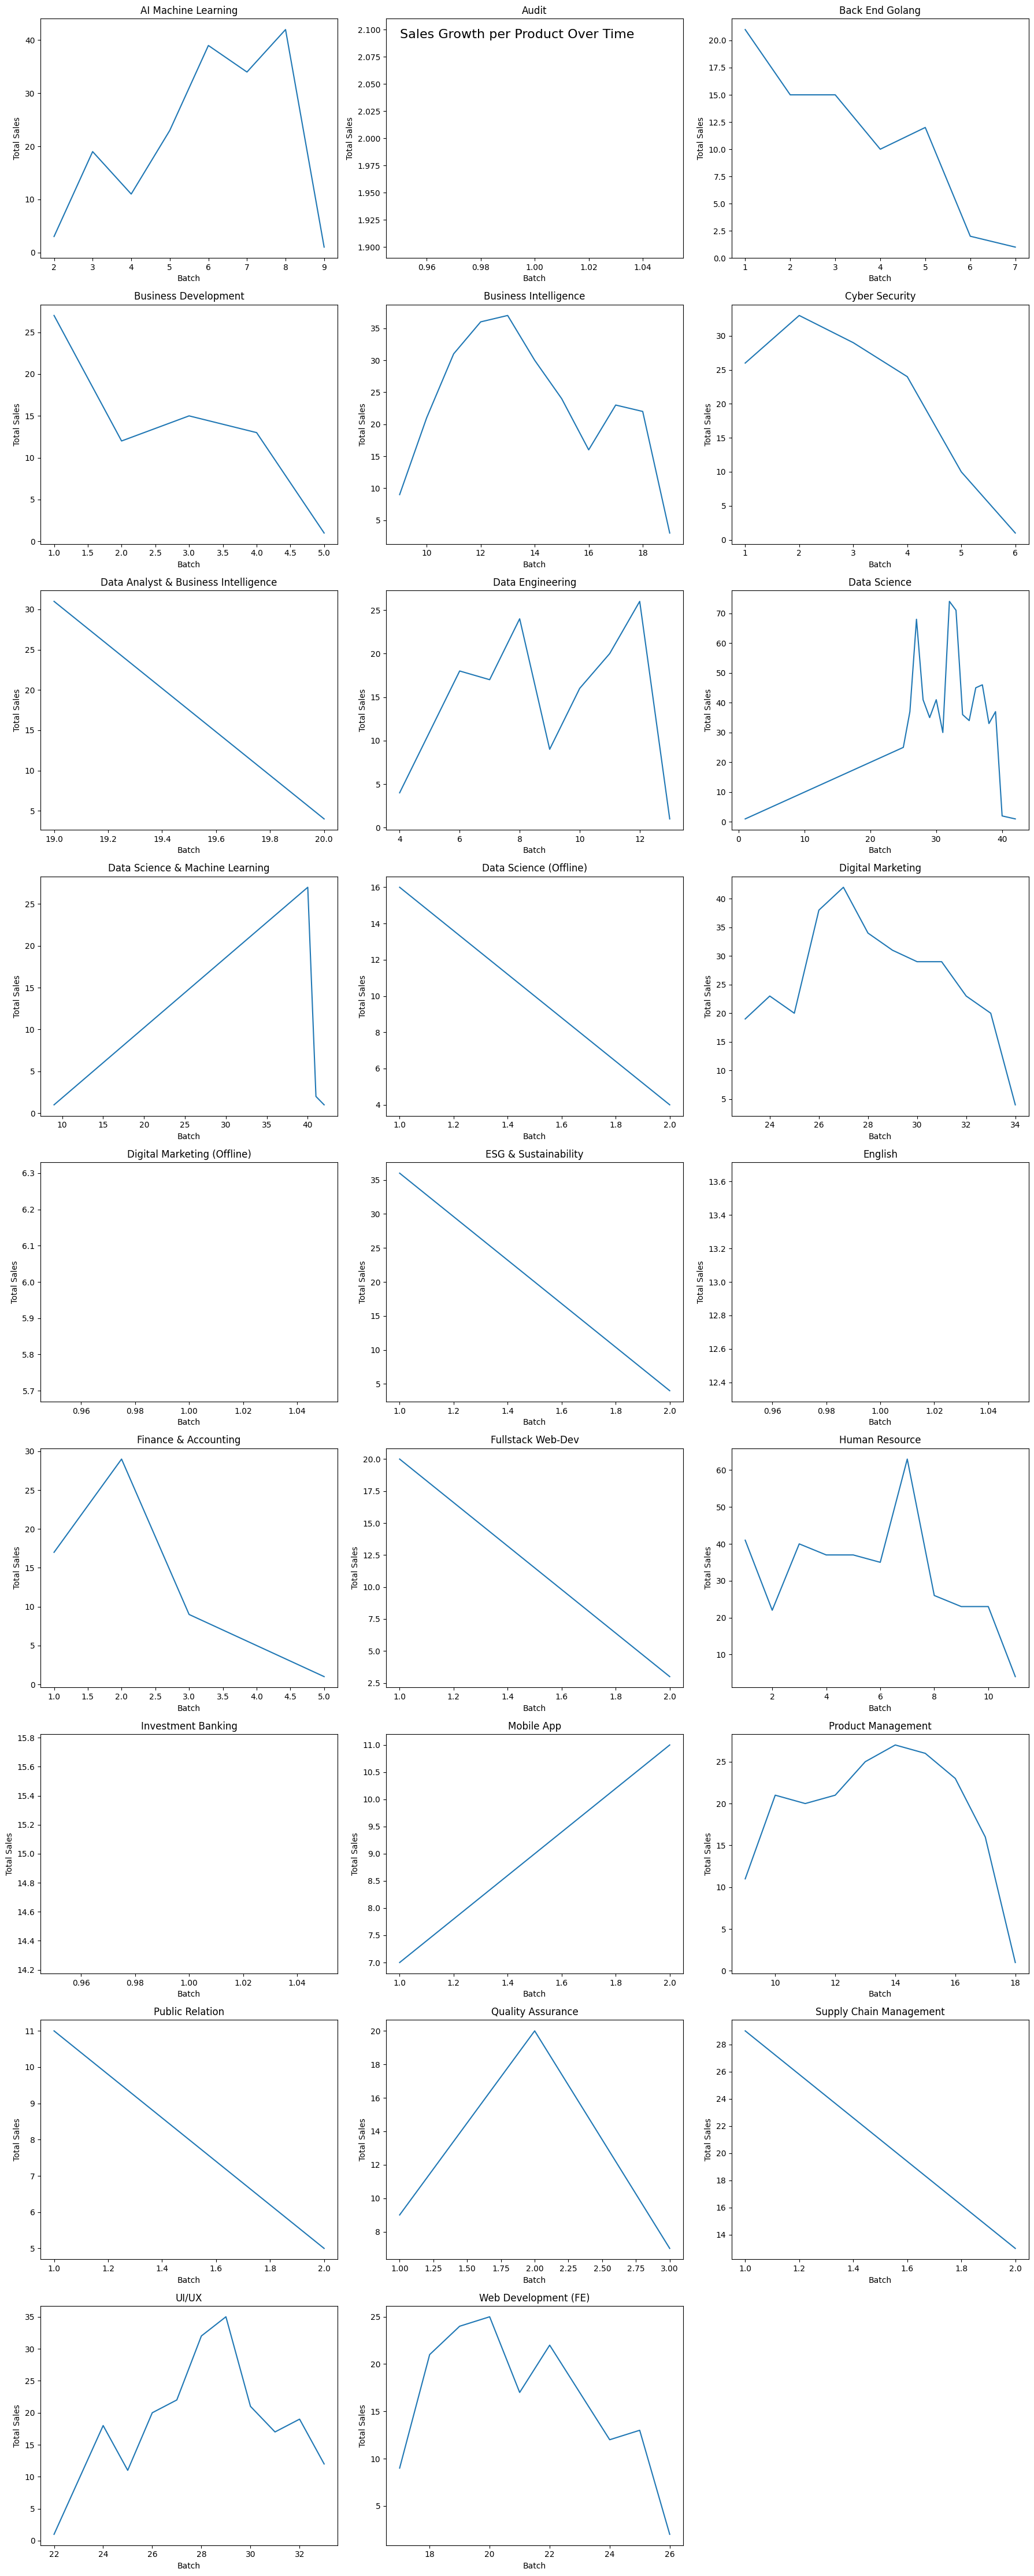

In [ ]:
# Growth comparison antar product
products = sales_per_batch['product'].unique()
n_products = len(products)

cols = 3  
rows = math.ceil(n_products / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, p in enumerate(products):
    df_product = sales_per_batch[sales_per_batch['product'] == p]

    axes[i].plot(df_product['batch'], df_product['total_sales'])
    axes[i].set_title(p)
    axes[i].set_xlabel('Batch')
    axes[i].set_ylabel('Total Sales')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sales Growth per Product Over Time', fontsize=16)
plt.tight_layout()
plt.show()

**Business Context:**

dibimbing.id is an Indonesian edtech company providing bootcamp programs in digital and technology domains (Data, Engineering, AI, Business, etc.). One of the business model is batch-based enrollment, where participants join a specific product and intake (batch). Revenue is primarily driven by the number of enrolled participants per product and per batch.

**Business Problem:**
In recent periods, several products have shown declining enrollments across new batches. However, it remains unclear whether this decline reflects a genuine drop in market demand, seasonal fluctuation, shifting customer preference, or incomplete/inconsistent reporting.

Without a structured enrollment performance monitoring system, management lacks clear visibility into product health, acquisition effectiveness, and batch-level growth dynamics, creating risk in planning, budgeting, and expansion decisions.

**Data Period:**
- Start: 2 January 2024
- End: 3 November 2025
- Duration: 671 days (~22 months)

**Business Objectives:** 
- Establish end-to-end enrollment performance monitoring framework
- Evaluate product-level growth and batch sustainability
- Identify high-performing and underperforming products early
- Assess acquisition channel effectiveness
- Analyze demographic trends to refine targeting strategy
- Develop short-term enrollment forecasting for strategic planning

**Business Vaulue:** 
- Improve visibility into real-time enrollment performance
- Enable data-driven batch sizing and scheduling decisions
- Optimize marketing budget allocation across acquisition channels
- Increase enrollment stability and reduce batch volatility
- Enable early detection of product demand deterioration
- Support scalable expansion strategy based on validated performance data


# Exploratory Data Analysis (EDA)

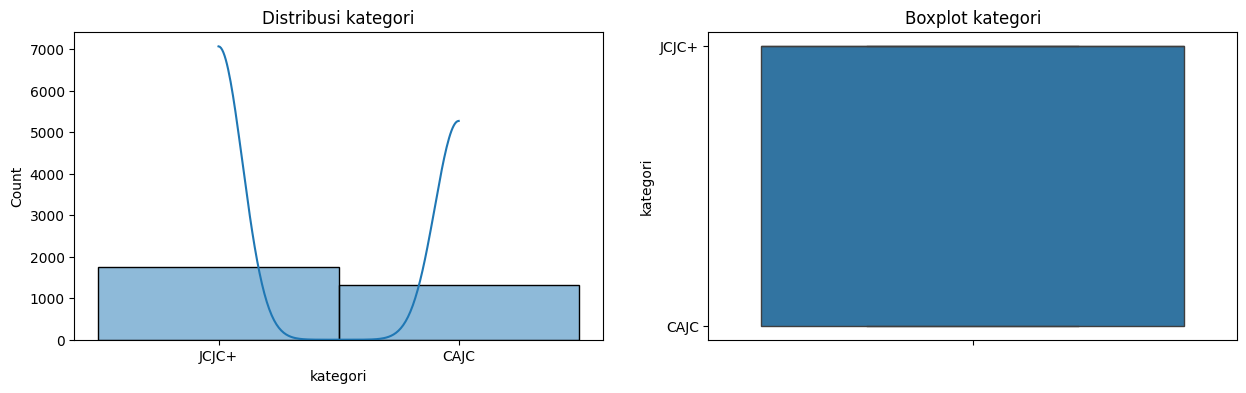

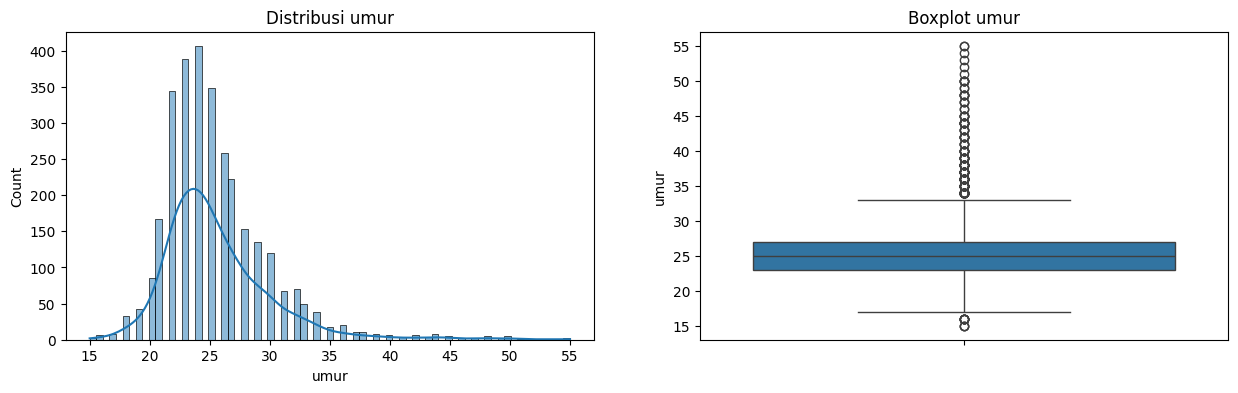

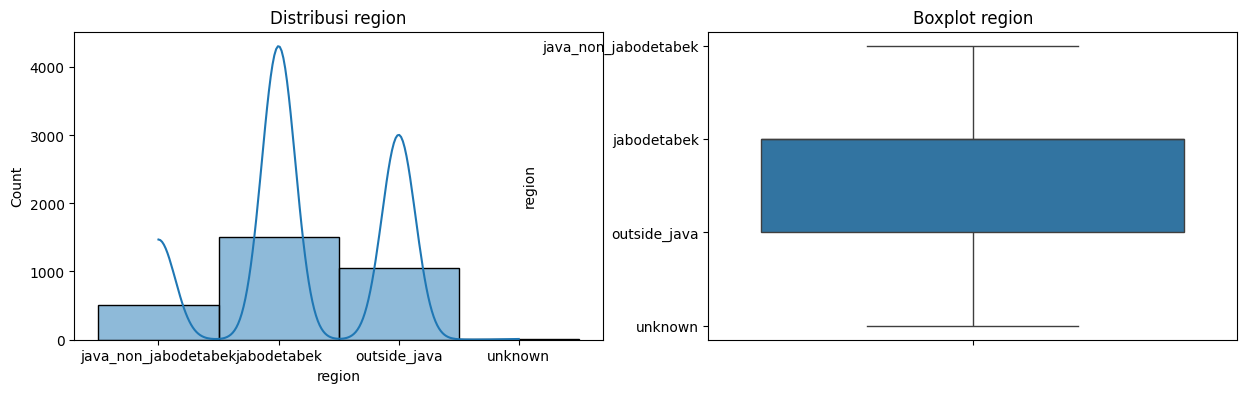

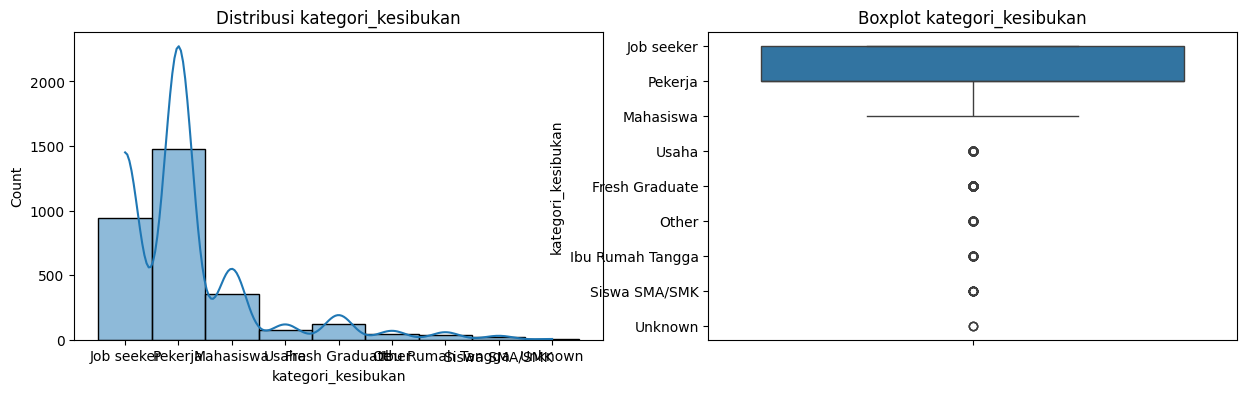

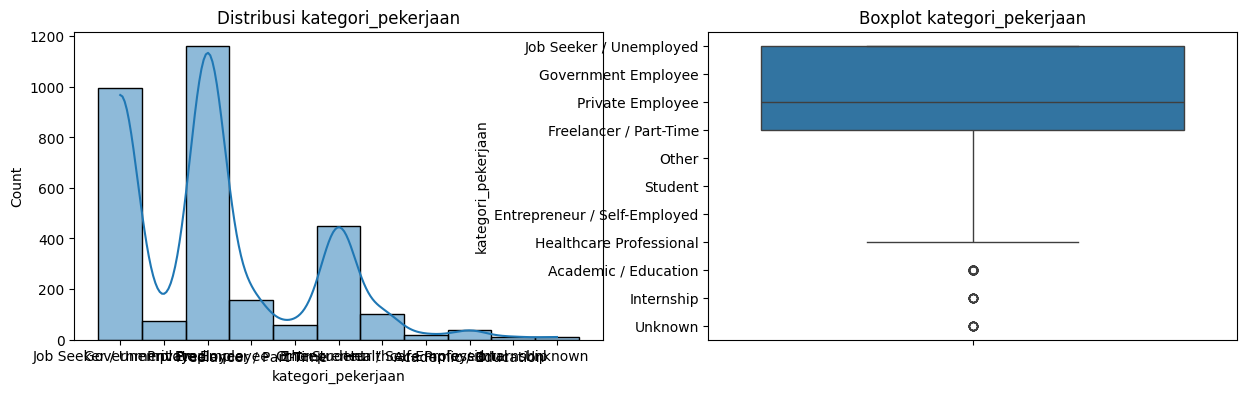

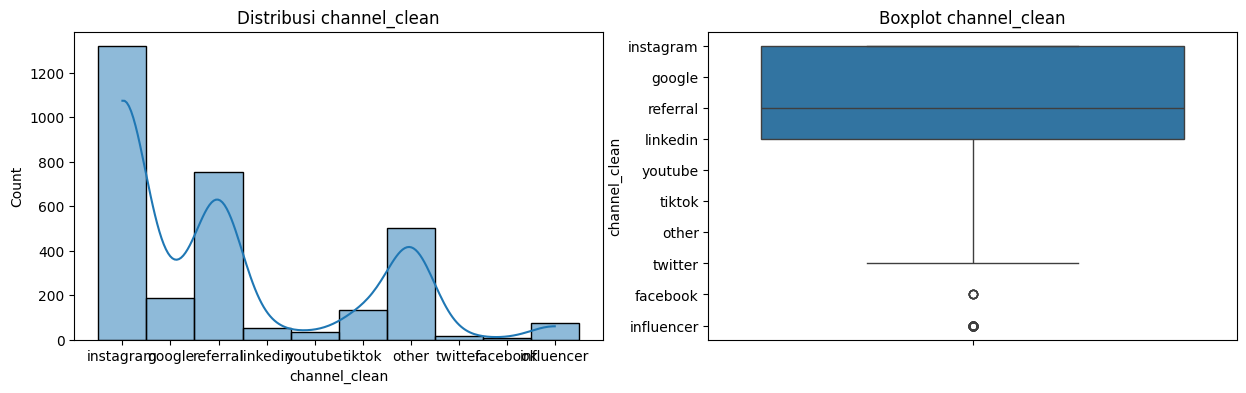

In [86]:
c = ["kategori", "umur", "region", "kategori_kesibukan", "kategori_pekerjaan", "channel_clean"]

for col in c:
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    sns.histplot(eda[col], kde=True)
    plt.title(f"Distribusi {col}")

    plt.subplot(1,2,2)
    sns.boxplot(eda[col])
    plt.title(f"Boxplot {col}")

    plt.tight_layout
    plt.show()

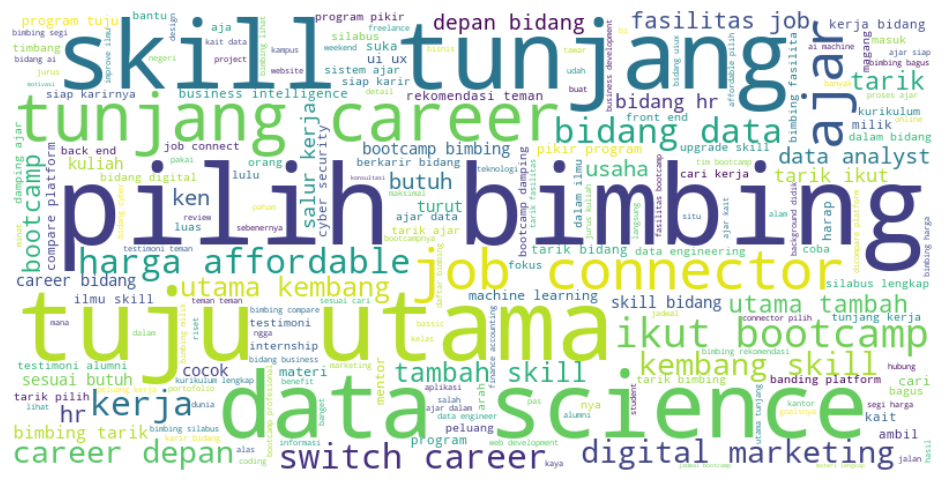

In [87]:
text_all = ' '.join(eda['motivation_cloud'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_all)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
# Channel impact analysis

In [88]:
# extraxt csv eda dataframe for dashboard
eda.to_csv("eda_dashboard.csv", index=False)

# Prediction: Monthly Product-Level Demand Forecasting

**Target Variable**

Y = Monthly Enrollment Count per Product

**Granularity**

month × product

## Data Preprocessing before Modeling

Choose data for forecast
Digital Marketing                              23
Data Engineering                               22
Data Science                                   22
Web Development (FE)                           22
UI/UX                                          22
Business Intelligence                          22
Product Management                             22

looping ini per produk di atas untuk menemukan min 10x batch
sales_per_batch = (
    eda.copy()
    .groupby(['product', 'batch'])
    .size()
    .reset_index(name='total_sales')
)
sales_per_batch = sales_per_batch.sort_values(['product', 'batch'])
 Growth per Product
sales_per_batch['sales_growth_%'] = (
    sales_per_batch
    .groupby('product')['total_sales']
    .pct_change() * 100
)
sales_per_batch.head()

## Encoding

## Scaling

# Modeling

# Final Evaluation

# Business Impact